# Session 06 — Estimation and confidence intervals

Revision ID: S06-r1  
Estimated time: 75–90 minutes  
Score: 40 points

**Question:** How precise is the estimated mean response time from a sample of benchmark runs?

## Learning outcomes

1. Calculate a point estimate, standard error, and t-based confidence interval for a mean.
2. Explain how sample size, sample spread, and confidence level affect interval width.
3. Interpret confidence as a long-run property of a procedure, not a probability for one fixed parameter.
4. Use simulation to inspect interval coverage and communicate limitations.

Run from the top. This notebook recreates the reference population from Session 05 so it works in a fresh kernel. The data are simulated teaching measurements, not production evidence. Complete S06-E1–E4 and label all intervals in milliseconds.

## From estimate to interval

The sample mean is a point estimate of a fixed population mean. It varies across random samples. The estimated standard error describes the sample-to-sample variability of that mean.

For an independent random sample from a population with finite variance, a two-sided t interval is

$$\bar{x} \pm t_{0.975, n-1} \frac{s}{\sqrt{n}}.$$

Here $s$ is the sample SD, $n$ is the sample size, and the critical value comes from a Student t distribution with $n-1$ degrees of freedom. The interval is in the original unit (milliseconds).

## Critical values provided for this exercise

Use this two-sided Student t lookup table. The degrees of freedom are $n-1$. The table keeps the computation within the packages already used in the course.

| n | df | 90% | 95% | 99% |
|---:|---:|---:|---:|---:|
| 10 | 9 | 1.833 | 2.262 | 3.250 |
| 30 | 29 | 1.699 | 2.045 | 2.756 |
| 100 | 99 | 1.660 | 1.984 | 2.626 |

In practice, use a verified t table or documented library function and match its tail area and degrees of freedom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

population_rng = np.random.default_rng(20260515)
population = population_rng.lognormal(mean=np.log(180), sigma=0.65, size=100_000)
population_mean = population.mean()
sample_rng = np.random.default_rng(20260615)

## State the sampling model

One observation is one simulated test-run response time. We draw 30 runs independently with replacement from the same reference population used in Session 05. The population mean is available here only because we generated the whole reference population; in a real study it would be unknown.

This interval procedure does not account for a biased test selection, dependent runs, instrumentation changes, or a new workload. Those are design and measurement questions, not interval-width adjustments.

In [2]:
sample = sample_rng.choice(population, size=30, replace=True)
n = sample.size
sample_mean = sample.mean()
sample_sd = sample.std(ddof=1)
standard_error = sample_sd / np.sqrt(n)
t_critical = 2.045  # 95% two-sided interval, df = 29
margin = t_critical * standard_error
lower = sample_mean - margin
upper = sample_mean + margin

estimate_table = pd.Series({
    "sample size": n,
    "sample mean (ms)": sample_mean,
    "sample SD (ms)": sample_sd,
    "standard error (ms)": standard_error,
    "t critical value": t_critical,
    "margin of error (ms)": margin,
    "lower limit (ms)": lower,
    "upper limit (ms)": upper,
    "reference population mean (ms)": population_mean,
})
display(estimate_table.round(2))

sample size                        30.00
sample mean (ms)                  193.27
sample SD (ms)                    138.29
standard error (ms)                25.25
t critical value                    2.04
margin of error (ms)               51.63
lower limit (ms)                  141.64
upper limit (ms)                  244.90
reference population mean (ms)    222.33
dtype: float64

## Read the interval in context

A 95% confidence procedure is designed so that, under its sampling assumptions, about 95% of intervals formed from repeated samples would cover the fixed population mean. After this interval is calculated, the mean is fixed; the interval either covers it or it does not.

Do not say that there is a 95% probability that this particular fixed mean lies inside this particular interval. State the estimate, the interval, the unit, the sample size, and the population/context represented by the sampling model.

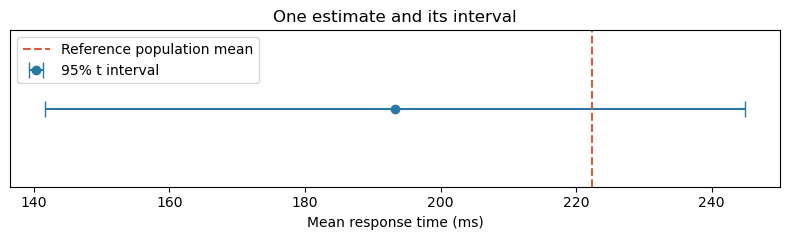

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.errorbar(sample_mean, 0, xerr=margin, fmt="o", capsize=6, color="#2878a0", label="95% t interval")
ax.axvline(population_mean, color="#d45d3f", linestyle="--", label="Reference population mean")
ax.set(title="One estimate and its interval", xlabel="Mean response time (ms)")
ax.set_yticks([])
ax.legend()
fig.tight_layout()
plt.show()

## Confidence level changes the width

Hold the sample and point estimate fixed. A higher confidence level requires a larger critical value and therefore a wider interval. It does not change the observed sample or its mean.

The 90%, 95%, and 99% intervals in the next table use the same standard error. Use the t critical values in the table above for $n=30$.

In [4]:
critical_by_level = {"90%": 1.699, "95%": 2.045, "99%": 2.756}
confidence_intervals = pd.DataFrame({
    level: [sample_mean - critical * standard_error, sample_mean + critical * standard_error]
    for level, critical in critical_by_level.items()
}, index=["lower (ms)", "upper (ms)"]).T
confidence_intervals["width (ms)"] = confidence_intervals["upper (ms)"] - confidence_intervals["lower (ms)"]
display(confidence_intervals.round(2))

,lower (ms),upper (ms),width (ms)
90%,150.37,236.16,85.79
95%,141.64,244.90,103.26
99%,123.69,262.85,139.17


## Sample size changes the standard error

Since $SE=s/\sqrt{n}$, larger samples usually produce narrower intervals when the sample spread is similar. The rate is a square root: about four times the sample size is needed to halve the standard error. A specific interval need not be perfectly narrower because its sample SD changes too.

In [5]:
t95_by_n = {10: 2.262, 30: 2.045, 100: 1.984}
size_rows = []
for sample_size, critical in t95_by_n.items():
    draw = sample_rng.choice(population, size=sample_size, replace=True)
    draw_mean = draw.mean()
    draw_sd = draw.std(ddof=1)
    draw_se = draw_sd / np.sqrt(sample_size)
    draw_margin = critical * draw_se
    size_rows.append({
        "n": sample_size,
        "mean (ms)": draw_mean,
        "SE (ms)": draw_se,
        "95% lower": draw_mean - draw_margin,
        "95% upper": draw_mean + draw_margin,
        "width (ms)": 2 * draw_margin,
    })
size_comparison = pd.DataFrame(size_rows).set_index("n")
display(size_comparison.round(2))

,mean (ms),SE (ms),95% lower,95% upper,width (ms)
n,,,,,
10,190.25,34.05,113.23,267.27,154.04
30,215.22,28.64,156.65,273.80,117.15
100,217.45,16.83,184.06,250.85,66.79


## Check coverage by repeated sampling

The reference mean is known in this simulation. For n=30 and n=300, repeat the t-interval procedure 5,000 times and count how often each interval covers that fixed mean. The population is strongly right-skewed, so do not assume a moderate sample automatically achieves nominal coverage. The observed coverage also has Monte Carlo variation.

This checks the procedure under one defined sampling model; it does not prove that real benchmark samples meet the same assumptions.

In [6]:
coverage_rng = np.random.default_rng(20260616)
coverage_rows = []
coverage_by_n = {}
for sample_size, critical in [(30, 2.045), (300, 1.968)]:
    draws = coverage_rng.choice(population, size=(5_000, sample_size), replace=True)
    coverage_means = draws.mean(axis=1)
    coverage_sds = draws.std(axis=1, ddof=1)
    coverage_se = coverage_sds / np.sqrt(sample_size)
    coverage_lowers = coverage_means - critical * coverage_se
    coverage_uppers = coverage_means + critical * coverage_se
    intervals_covered = (coverage_lowers <= population_mean) & (population_mean <= coverage_uppers)
    coverage_by_n[sample_size] = intervals_covered.mean()
    coverage_rows.append({
        "n": sample_size,
        "intervals": intervals_covered.size,
        "covered": int(intervals_covered.sum()),
        "empirical coverage": intervals_covered.mean(),
    })
coverage_summary = pd.DataFrame(coverage_rows).set_index("n")
display(coverage_summary)

,intervals,covered,empirical coverage
n,,,
30,5000,4592,0.9184
300,5000,4717,0.9434


## Optional extension: bootstrap percentile interval

Resample the observed sample with replacement, calculate a mean for each bootstrap resample, and take the 2.5th and 97.5th percentiles. This is a computational comparison, not a cure for biased sampling. The resamples reuse the observed data and cannot supply missing workloads or measurement conditions.

In [7]:
bootstrap_rng = np.random.default_rng(20260617)
bootstrap_indices = bootstrap_rng.integers(0, n, size=(2_000, n))
bootstrap_means = sample[bootstrap_indices].mean(axis=1)
bootstrap_interval = np.quantile(bootstrap_means, [0.025, 0.975])
print(f"Bootstrap percentile interval: [{bootstrap_interval[0]:.2f}, {bootstrap_interval[1]:.2f}] ms")

Bootstrap percentile interval: [148.39, 245.15] ms


## S06-E1 — Calculate and report a t interval

Using the sample of 30 runs, report the sample mean, standard error, margin of error, and 95% t interval. Include milliseconds and n. Write one sentence interpreting the interval for the reference population represented by this simulation.

In [8]:
# TODO: create a labeled result table using sample_mean, standard_error, margin, lower, and upper.
e1_result = None
if e1_result is not None:
    display(e1_result)

## S06-E2 — Compare confidence level and n

Use `confidence_intervals` and `size_comparison`. Explain why the interval width changes when the confidence level increases, and why larger n usually narrows an interval. Mention one reason a particular pair of intervals may not follow a perfectly ordered width pattern.

In [9]:
# TODO: select and display the widths you use, then write a short interpretation.
e2_response = ""

## S06-E3 -- Interpret simulated coverage

Compare empirical coverage for n=30 and n=300 with the nominal 0.95. Explain why finite simulation results need not equal 0.95 exactly, why the skewed population may affect the smaller-sample t intervals, and what repeated-sampling interpretation is appropriate. Do not assign a 95% probability to the fixed population mean after observing one interval.

In [10]:
# TODO: write two or three sentences using the simulated coverage result.
e3_response = ""

## S06-E4 — Correct a common confidence-interval claim

A report says: 'There is a 95% probability that the fixed population mean is inside this calculated interval.' Rewrite the statement accurately. Name one sampling or measurement limitation that this interval does not address.

In [11]:
# TODO: write a corrected interpretation and one limitation.
e4_response = ""

## Synthesis

A confidence interval combines an estimate, its standard error, and a critical value. A higher confidence level widens the interval; a larger sample usually narrows it. Confidence describes the long-run behavior of a procedure under a sampling model. It does not guarantee representativeness or causal interpretation.

**Exit ticket:** Finish both statements: 'A 95% confidence procedure means...' and 'It does not mean...'.